In [35]:
import numpy as np
import struct
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [36]:
def load_mnist_images(filename, max_samples=None):
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
        images = images.reshape(num, -1)
        images = images.astype(np.float32) / 255.0
        if max_samples:
            images = images[:max_samples]
        return images

def load_mnist_labels(filename, max_samples=None):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        if max_samples:
            labels = labels[:max_samples]
        return labels

In [37]:
train_images = load_mnist_images('train-images.idx3-ubyte')
train_labels = load_mnist_labels('/content/train-labels.idx1-ubyte')

test_images = load_mnist_images('/content/t10k-images.idx3-ubyte')
test_labels = load_mnist_labels('/content/t10k-labels.idx1-ubyte')
train_images=train_images[:10000]
train_labels=train_labels[:10000]

print("Train images:", train_images.shape)
print("Train labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Train images: (10000, 784)
Train labels: (10000,)
Test images: (10000, 784)
Test labels: (10000,)


In [42]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42)
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(train_images, train_labels)
    trained[name] = model
    print(f"  Done.")

Training Logistic Regression...
  Done.
Training Random Forest...
  Done.
Training KNN...
  Done.
Training Decision Tree...
  Done.


In [43]:
results = {}
for name, model in trained.items():
    y_pred = model.predict(test_images)
    acc = accuracy_score(test_labels, y_pred)
    results[name] = acc
    print(f"\n{'='*40}")
    print(f"{name}  |  Accuracy: {acc:.4f}")
    print(classification_report(test_labels, y_pred))


Logistic Regression  |  Accuracy: 0.9042
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       980
           1       0.95      0.97      0.96      1135
           2       0.90      0.87      0.89      1032
           3       0.88      0.89      0.89      1010
           4       0.90      0.92      0.91       982
           5       0.87      0.84      0.86       892
           6       0.92      0.94      0.93       958
           7       0.91      0.92      0.91      1028
           8       0.85      0.86      0.85       974
           9       0.89      0.86      0.87      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


Random Forest  |  Accuracy: 0.9503
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.98      0.99      0.98      1135


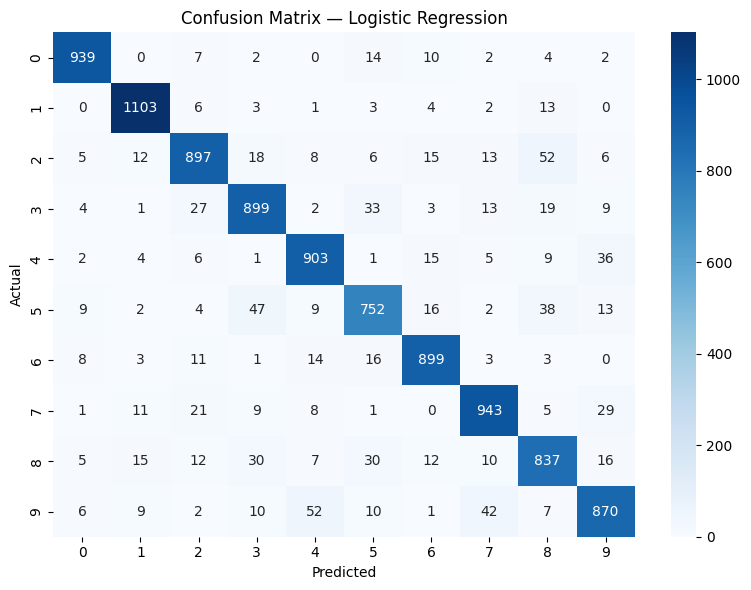

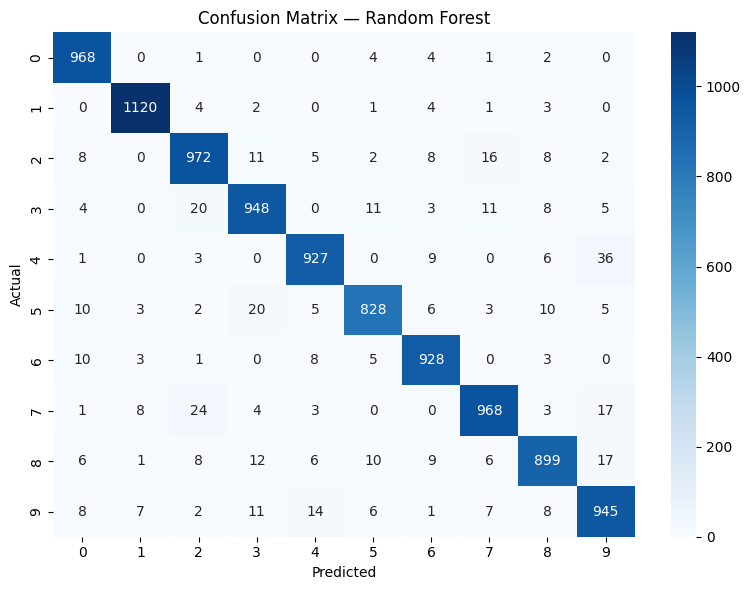

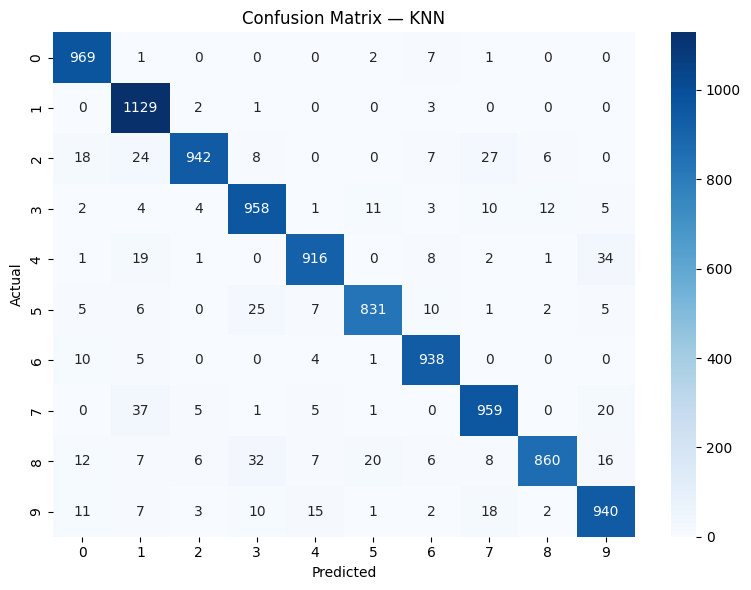

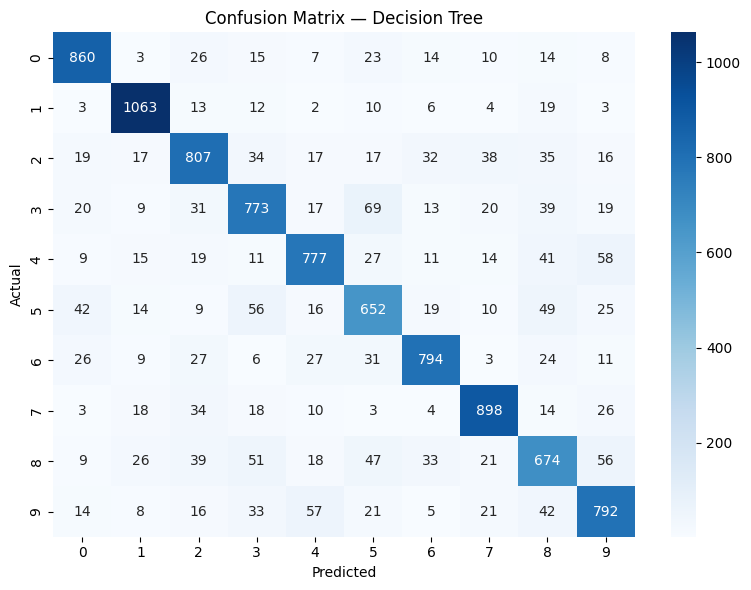

In [44]:
for name, model in trained.items():
    y_pred = model.predict(test_images)
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

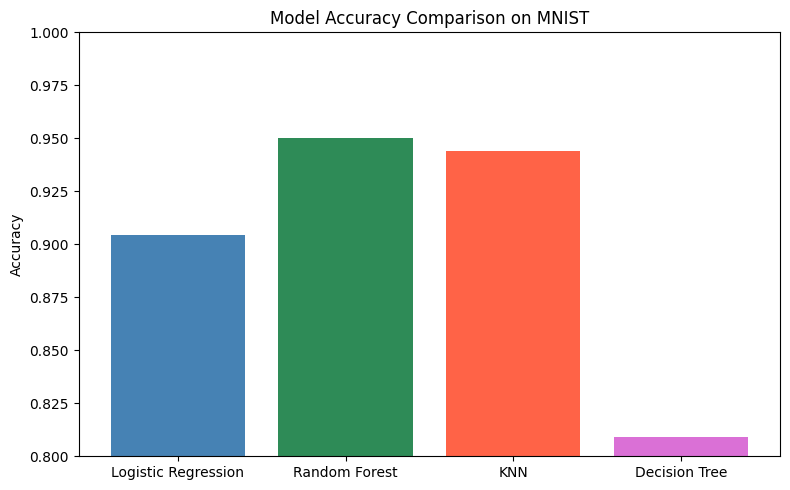

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'seagreen', 'tomato', 'orchid'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison on MNIST')
plt.tight_layout()
plt.show()